# DTLZ2 Results

In [1]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 10
NPOP = 800
NGEN = 300
NOBJ = 4 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz2_segura = partial(benchmarks.dtlz2, obj=NOBJ)
toolbox = build_toolbox(func_dtlz2_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 20
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


[[0.0, 0.0, 0.0, 0.5000004123280299, 0.5045003464570078, 0.488073949964056, 0.5000118428480264, 0.5001423178859778, 0.5000533745985245, 0.4999707244266057, 0.4999837425492715, 0.500547296818633, 0.499996907788504], [0.0, 0.0, 0.0, 0.5000004123280299, 0.5045003464570078, 0.488073949964056, 0.5000118428480264, 0.5001423178859778, 0.5000533745985245, 0.4999707244266057, 0.4999837425492715, 0.500547296818633, 0.499996907788504], [0.9999999999999954, 0.0, 0.0, 0.5000097515127963, 0.4999385690717206, 0.500409805344153, 0.5000150846665715, 0.5011148260235744, 0.4984507120757716, 0.4999885900958077, 0.4996333241075817, 0.4998743795547109, 0.49943171463138064], [0.9999999997419516, 1.0, 0.0, 0.4863922523035191, 0.4995091882397856, 0.4999775992219669, 0.50106560086282, 0.5000103800639906, 0.5000182973281028, 0.4845589004194583, 0.4999839645101866, 0.5000482742356763, 0.5003300024266766], [0.0, 0.9999999999999977, 0.0005826197404713101, 0.6431645141838835, 0.4967335384195135, 0.023313319088104162

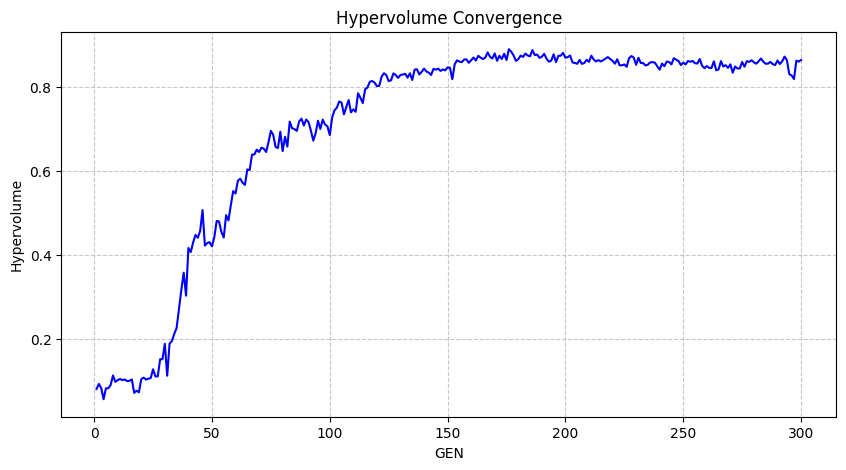

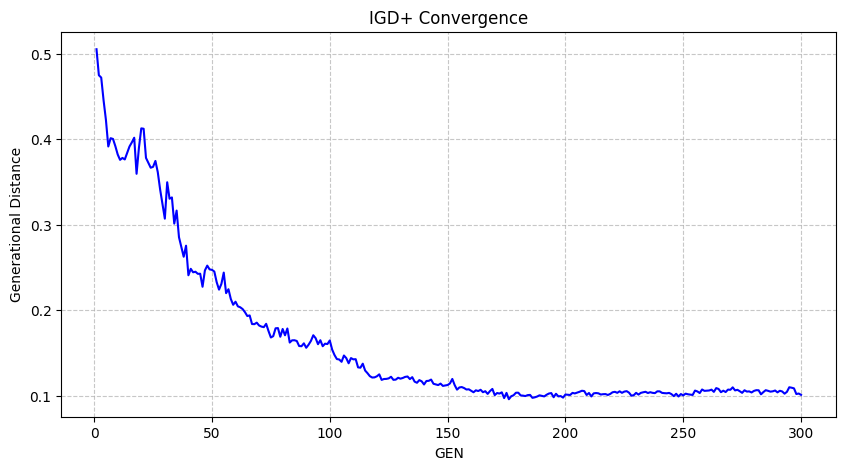

In [2]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
print(tabelas[0])
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
\
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()